In [12]:
# the purpose of this notebook is to train polynomial, random forest, and GPR models 
# on our data and compare using LOOCV. 

In [13]:
# import data

from pathlib import Path
import pandas as pd

# Load the compiled data
project_root = Path.cwd().resolve().parent if 'notebooks' in str(Path.cwd()) else Path.cwd().resolve()
excel_path = project_root / 'data' / 'raw' / 'Compiled Data.xlsx'

df = pd.read_excel(excel_path)

c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Brooke Bro

LOOCV performance for all models:


c:\Users\Brooke Brocker\foam-project\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,Model,Property,R²,MAE,RMSE
0,Polynomial (degree 2),Average density (g/cm³),0.8165,0.0225,0.0274
1,Polynomial (degree 2),24 h absorption (%),0.8504,23.0520,30.0278
2,Polynomial (degree 2),24 h retention (%),-1.2046,12.2651,19.2614
3,Random forest,Average density (g/cm³),0.8079,0.0215,0.0280
4,Random forest,24 h absorption (%),0.9303,16.8501,20.4899
5,Random forest,24 h retention (%),0.5156,6.3859,9.0287
6,Gaussian process (separate per property),Average density (g/cm³),0.8658,0.0188,0.0234
7,Gaussian process (separate per property),24 h absorption (%),0.8596,22.8043,29.0898
8,Gaussian process (separate per property),24 h retention (%),0.7346,5.0162,6.6832


GPR details (final models fitted on all 25 samples):


,LOOCV R²,LOOCV MAE,LOOCV RMSE,Optimized kernel (all 25 samples)
Property,,,,
Average density (g/cm³),0.865830,0.018787,0.023439,"0.973**2 * Matern(length_scale=[0.232, 1.22, 1..."
24 h absorption (%),0.859557,22.804300,29.089821,"0.907**2 * Matern(length_scale=[3.26, 2.2, 4.5..."
24 h retention (%),0.734585,5.016151,6.683205,"1.06**2 * Matern(length_scale=[8.06, 0.563, 1...."


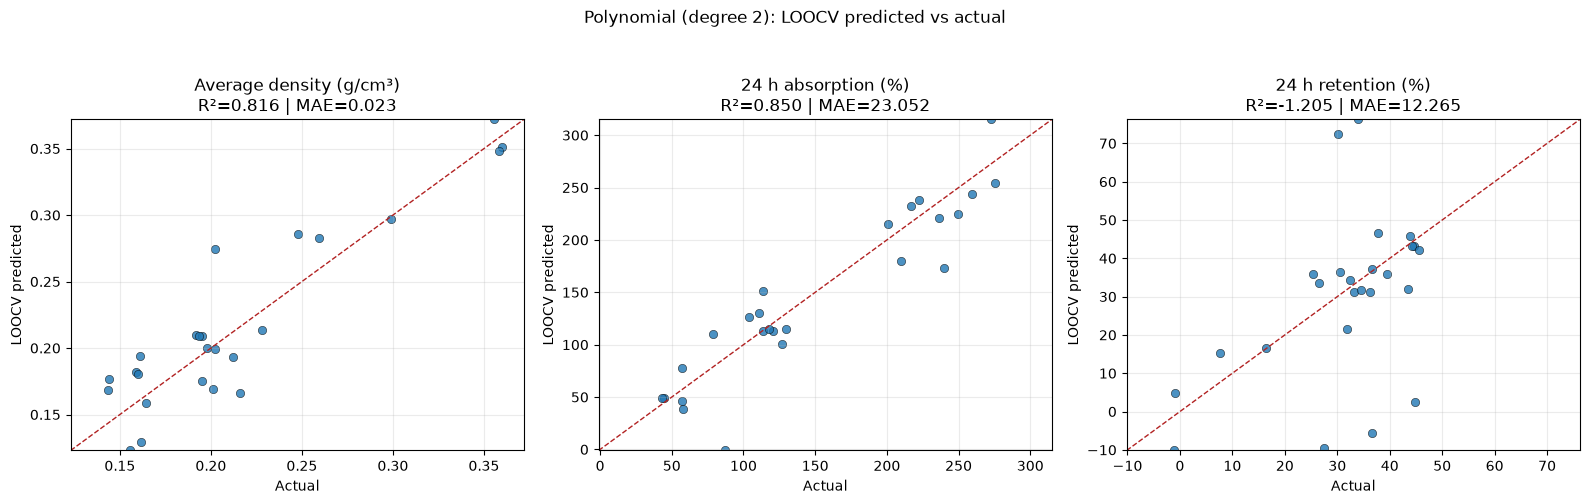

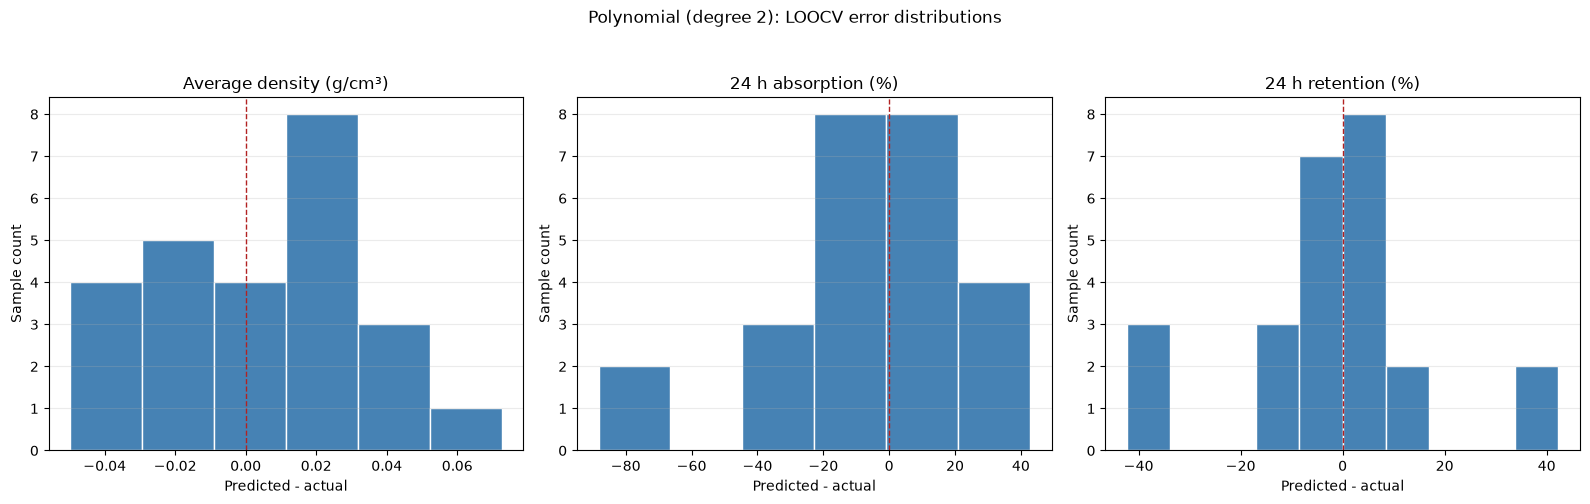

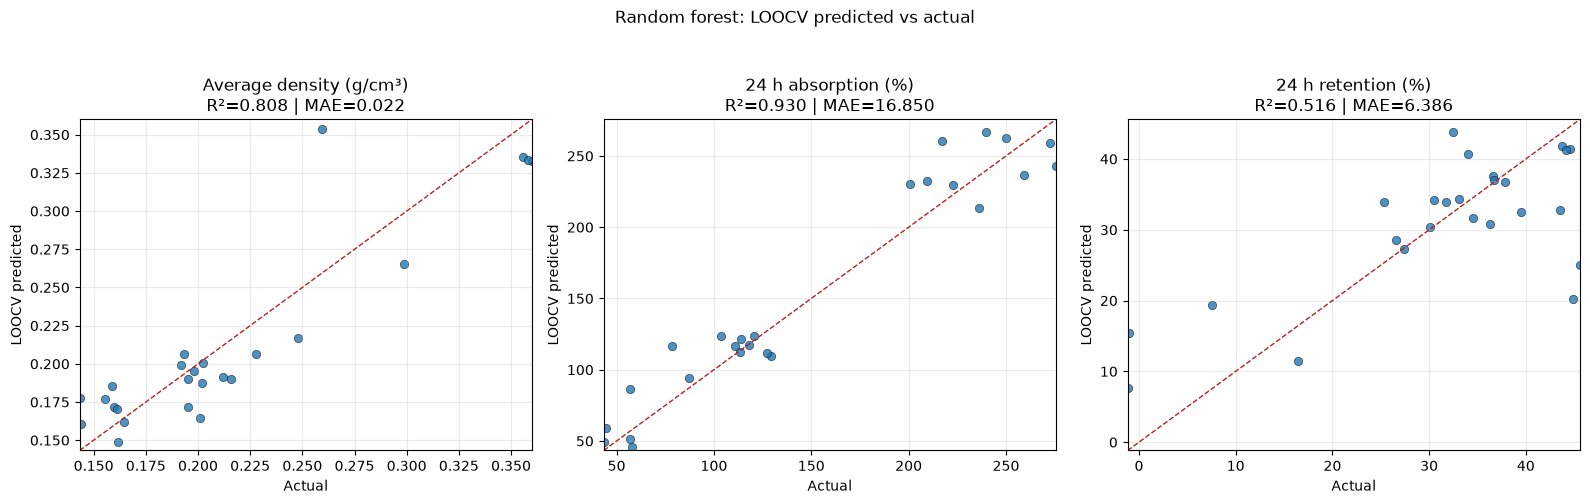

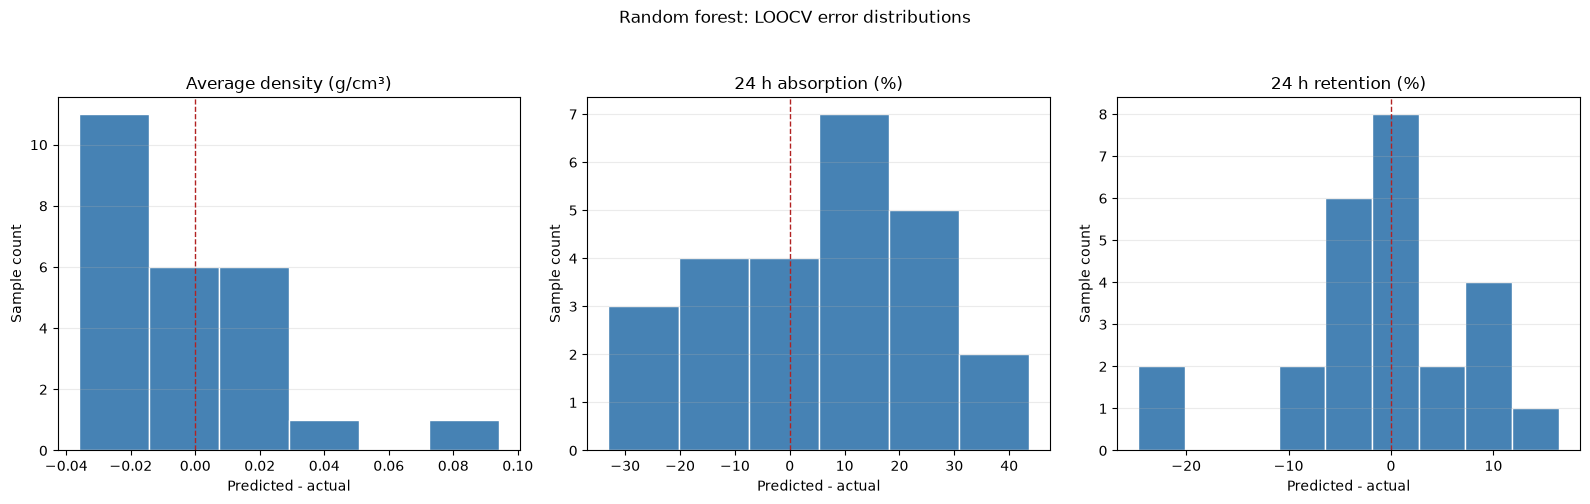

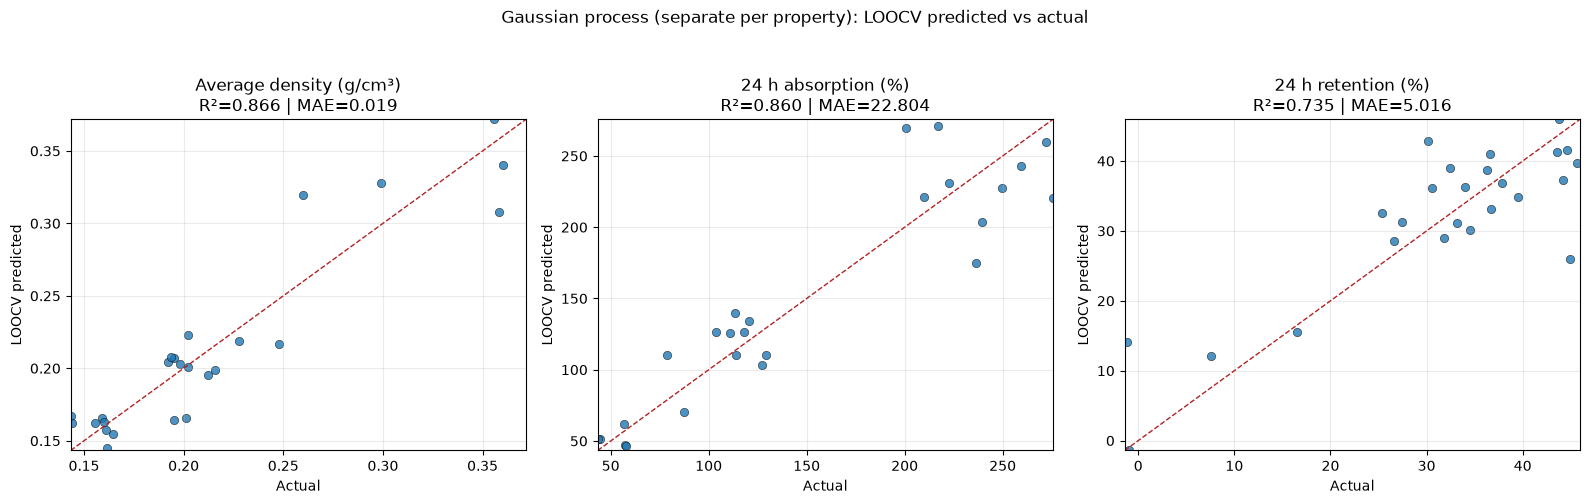

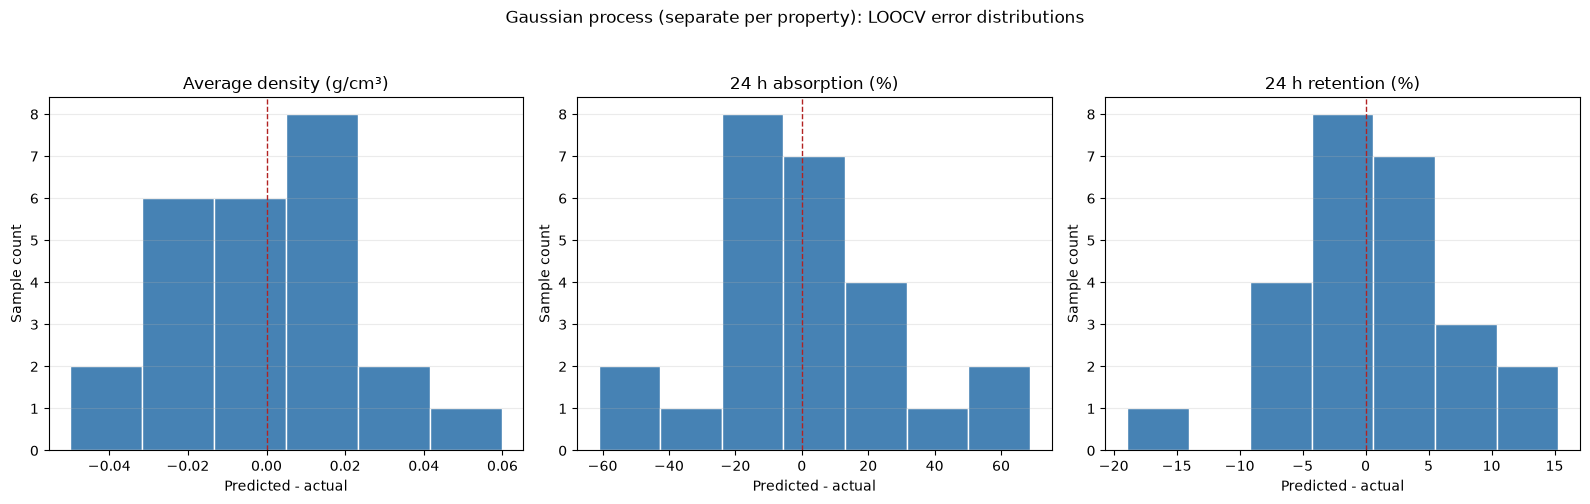

LOOCV predictions per property: 25


In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

feature_cols = ["TEM", "Joncryl", "NC513", "PEG-DE", "NGDE"]
target_cols = [
    "Avg_Density_g_cm3",
    "24h_avg_pct absorption",
    "24h_avg_pct_retention",
]
target_labels = ["Average density (g/cm³)", "24 h absorption (%)", "24 h retention (%)"]

# Blank ingredient cells represent ingredients absent from a formulation.
model_data = df[feature_cols + target_cols].copy()
model_data[feature_cols] = model_data[feature_cols].fillna(0.0)
model_data[target_cols] = model_data[target_cols].apply(pd.to_numeric, errors="raise")
assert len(model_data) == 25, f"Expected all 25 samples; found {len(model_data)}."
assert not model_data[target_cols].isna().any().any(), "A target contains missing values."

X = model_data[feature_cols]                    # input features
y = model_data[target_cols]                     # targets
loo = LeaveOneOut()
models = {
    "Polynomial (degree 2)": make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2, include_bias=False),
        LinearRegression(),
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=500,                       # number of decision trees
        random_state=42,
        n_jobs=-1,
    ),
}

cv_predictions = {                                                      
    name: cross_val_predict(model, X, y, cv=loo, n_jobs=1)                      # takes the polynomial and random forest models and does LOOCV, so we have 1 model the predicts all 3 targets
    for name, model in models.items()
}

# Fit an independent GPR for each target, then fit its final model on all samples.
gpr_predictions = np.empty((len(X), len(target_cols)))
gpr_models = {}
gpr_results = []
for target_idx, target in enumerate(target_cols):
    target_values = y[target]
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(
            length_scale=np.ones(len(feature_cols)),
            length_scale_bounds=(1e-2, 1e3),
            nu=2.5,
        )
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
    )
    estimator = make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            n_restarts_optimizer=5,
            random_state=42,
        ),
    )

    # cross_val_predict refits on each of the 25 leave-one-out training folds.
    oof_prediction = cross_val_predict(
        clone(estimator), X, target_values, cv=loo, n_jobs=1
    )
    gpr_predictions[:, target_idx] = oof_prediction

    final_model = clone(estimator).fit(X, target_values)
    gpr_models[target] = final_model
    gpr_results.append(
        {
            "Property": target_labels[target_idx],
            "LOOCV R²": r2_score(target_values, oof_prediction),
            "LOOCV MAE": mean_absolute_error(target_values, oof_prediction),
            "LOOCV RMSE": np.sqrt(mean_squared_error(target_values, oof_prediction)),
            "Optimized kernel (all 25 samples)": str(
                final_model.named_steps["gaussianprocessregressor"].kernel_
            ),
        }
    )

cv_predictions["Gaussian process (separate per property)"] = gpr_predictions

metric_rows = []
for model_name, predictions in cv_predictions.items():
    for target_idx, target_label in enumerate(target_labels):
        actual = y.iloc[:, target_idx].to_numpy()
        predicted = predictions[:, target_idx]
        metric_rows.append(
            {
                "Model": model_name,
                "Property": target_label,
                "R²": r2_score(actual, predicted),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
            }
        )

metrics = pd.DataFrame(metric_rows)
print("LOOCV performance for all models:")
display(metrics.round(4))
print("GPR details (final models fitted on all 25 samples):")
display(pd.DataFrame(gpr_results).set_index("Property"))

for model_name, predictions in cv_predictions.items():
    figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for target_idx, (axis, target_label) in enumerate(zip(axes, target_labels)):
        actual = y.iloc[:, target_idx].to_numpy()
        predicted = predictions[:, target_idx]
        lower = min(actual.min(), predicted.min())
        upper = max(actual.max(), predicted.max())
        score = r2_score(actual, predicted)
        error = mean_absolute_error(actual, predicted)

        axis.scatter(actual, predicted, alpha=0.8, edgecolor="black", linewidth=0.4)
        axis.plot([lower, upper], [lower, upper], "--", color="firebrick", linewidth=1)
        axis.set(
            xlabel="Actual",
            ylabel="LOOCV predicted",
            title=f"{target_label}\nR²={score:.3f} | MAE={error:.3f}",
        )
        axis.set_xlim(lower, upper)
        axis.set_ylim(lower, upper)
        axis.grid(alpha=0.25)

    figure.suptitle(f"{model_name}: LOOCV predicted vs actual", y=1.04)
    figure.tight_layout()
    plt.show()

    figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for target_idx, (axis, target_label) in enumerate(zip(axes, target_labels)):
        residuals = predictions[:, target_idx] - y.iloc[:, target_idx].to_numpy()
        axis.hist(residuals, bins="auto", color="steelblue", edgecolor="white")
        axis.axvline(0, color="firebrick", linestyle="--", linewidth=1)
        axis.set(xlabel="Predicted - actual", ylabel="Sample count", title=target_label)
        axis.grid(axis="y", alpha=0.25)

    figure.suptitle(f"{model_name}: LOOCV error distributions", y=1.04)
    figure.tight_layout()
    plt.show()

print(f"LOOCV predictions per property: {len(X)}")